In [5]:
# import libraries
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, ModelCheckpoint

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("youssefsalahzakria/fruit-and-vegetables-classification")

print("Path to dataset files:", path)

Resuming download from 1455423488 bytes (3723516660 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/youssefsalahzakria/fruit-and-vegetables-classification?dataset_version_number=5 (1455423488/5178940148) bytes left.


100%|██████████| 4.82G/4.82G [00:43<00:00, 86.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/youssefsalahzakria/fruit-and-vegetables-classification/versions/5


In [20]:
# Paths

# DATA_DIR = "dataset"
DATA_DIR = path

MODEL_PATH = "models/ingredient_model.keras"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCH = 30

In [8]:
# Datagen preparation
train_datagen = ImageDataGenerator(rescale=1./255)

# Add validation and test datagen
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR + "/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    DATA_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 46187 images belonging to 50 classes.
Found 12544 images belonging to 50 classes.
Found 13353 images belonging to 50 classes.


In [9]:
print(DATA_DIR)

/root/.cache/kagglehub/datasets/youssefsalahzakria/fruit-and-vegetables-classification/versions/5


In [10]:
# print class names
if os.path.isdir(DATA_DIR + "/train"):
    CLASS_NAMES = sorted(os.listdir(DATA_DIR + "/train"))

print(CLASS_NAMES)

['Apple', 'Avocado', 'Banana', 'Beetroot', 'Blackberry', 'Blueberry', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chilli Peper', 'Corn', 'Cucumber', 'Dates', 'Dragonfruit', 'Eggplant', 'Fig', 'Garlic', 'Ginger', 'Grapes', 'Guava', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Mango', 'Mushroom', 'Okra', 'Olive', 'Onion', 'Orange', 'Paprika', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Pomegranate', 'Potato', 'Pumpkin', 'Raddish', 'Rambutan', 'Soy Beans', 'Spinach', 'Strawberry', 'Sweetcorn', 'Sweetpotato', 'Tomato', 'Turnip', 'Watermelon']


In [11]:
# Model compilation
base_model = MobileNetV2(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False  # freeze for fast training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
# add earlystoping callbacks
Callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.25, patience=3, verbose=1)
]

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,598,770 (9.91 MB)

 Trainable params: 340,786 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [13]:
# train top layers only
print("Training started...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    callbacks=Callbacks
)

# save model
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH)
print(f"Model saved TO {MODEL_PATH}")

Training started...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
 90/722 ━━━━━━━━━━━━━━━━━━━━ 3:38 346ms/step - accuracy: 0.3263 - loss: 2.8605

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


722/722 ━━━━━━━━━━━━━━━━━━━━ 294s 380ms/step - accuracy: 0.6162 - loss: 1.5077 - val_accuracy: 0.8365 - val_loss: 0.5824 - learning_rate: 0.0010
Epoch 2/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 243s 337ms/step - accuracy: 0.8203 - loss: 0.6088 - val_accuracy: 0.8483 - val_loss: 0.5384 - learning_rate: 0.0010
Epoch 3/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 243s 337ms/step - accuracy: 0.8544 - loss: 0.4811 - val_accuracy: 0.8586 - val_loss: 0.5036 - learning_rate: 0.0010
Epoch 4/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 239s 330ms/step - accuracy: 0.8753 - loss: 0.3994 - val_accuracy: 0.8680 - val_loss: 0.4801 - learning_rate: 0.0010
Epoch 5/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 234s 324ms/step - accuracy: 0.8989 - loss: 0.3321 - val_accuracy: 0.8728 - val_loss: 0.4615 - learning_rate: 0.0010
Epoch 6/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 236s 326ms/step - accuracy: 0.9034 - loss: 0.3013 - val_accuracy: 0.8729 - val_loss: 0.4929 - learning_rate: 0.0010
Epoch 7/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 234s 324ms/step - accuracy: 0.9194 

In [21]:
# use another model format
MODEL_PATH = "models/ingredient_model.h5"

# save model
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH)
print(f"Model saved TO {MODEL_PATH}")

Model saved TO models/ingredient_model.h5


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Get the model path from the notebook state
model_file_path = MODEL_PATH

# Create the zip file
zip_file_name = "model.zip"
!zip -r {zip_file_name} {model_file_path}

print(f"Model '{model_file_path}' zipped to '{zip_file_name}'")

In [ ]:
!cp /content/model.zip /content/drive/MyDrive/

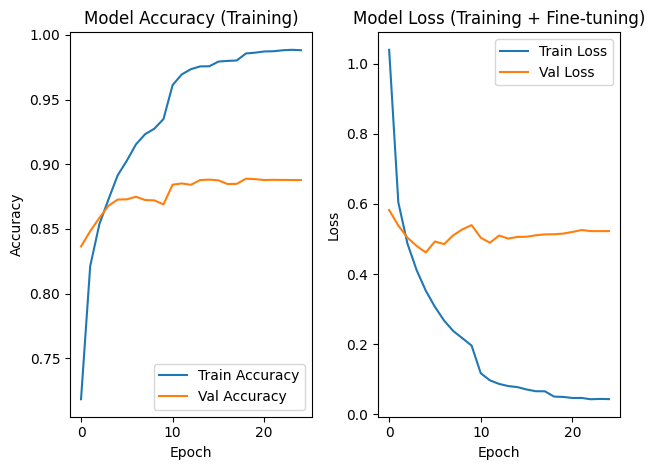

In [18]:
# Plot training history

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Model Accuracy (Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Model Loss (Training + Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()